# Ejemplo real, trabajo en construcción


## ENDEI: Encuesta Nacional de Empleo e Ingresos de Argentina

La **ENDEI (Encuesta Nacional de Empleo e Ingresos)** es una encuesta estadística oficial de Argentina que recopila información detallada sobre el mercado laboral y los ingresos de la población. Esta encuesta es fundamental para comprender la dinámica del empleo y la distribución de ingresos en el país.

### Propósito y alcance

La ENDEI tiene como objetivo principal proporcionar información estadística confiable sobre:

- **Empleo y desempleo**: Tasas de ocupación, desocupación y actividad económica
- **Características del trabajo**: Tipo de ocupación, sector económico, modalidad de contratación
- **Ingresos laborales**: Salarios, remuneraciones y distribución del ingreso
- **Condiciones laborales**: Horarios, beneficios sociales, seguridad laboral
- **Perfil demográfico**: Características de la población económicamente activa

### Desafíos metodológicos

Trabajar con la ENDEI presenta varios desafíos significativos:

#### Complejidad del diseño muestral

- **Muestreo estratificado**: La encuesta utiliza un diseño complejo que requiere ponderaciones específicas para cada observación
- **Rotación de panel**: Los hogares participan en múltiples ondas, generando dependencias temporales
- **Ajustes estacionales**: Los patrones laborales varían significativamente a lo largo del año

#### Calidad y consistencia de datos

- **Valores faltantes**: Presencia de datos no reportados que requieren técnicas de imputación
- **Inconsistencias lógicas**: Contradicciones entre variables relacionadas que necesitan validación
- **Cambios metodológicos**: Modificaciones en el cuestionario o procedimientos de recolección

#### Análisis estadístico avanzado

- **Ponderaciones**: Necesidad de incorporar factores de expansión para obtener estimaciones poblacionales válidas
- **Errores de muestreo**: Cálculo de intervalos de confianza considerando el diseño muestral
- **Análisis longitudinal**: Son datos cross-section, por lo que en principio se descarta el uso de datos de panel con correlaciones temporales





In [85]:
import pandas as pd
import os

# Verificar que el directorio Data existe
if not os.path.exists('Data'):
    os.makedirs('Data')

# Cargar el archivo .dta (pandas.read_stata no acepta el parámetro encoding)
df = pd.read_stata('Data/Endei3_v_2024/Resultados REDPYMES 2024 - ENDEI 3 - 2025.dta')

# Convertir columnas categóricas a string para evitar problemas con parquet
categorical_columns = df.select_dtypes(include=['category']).columns
for col in categorical_columns:
    df[col] = df[col].astype(str)

# Guardar como parquet
output_path = 'Data/endei_2024.parquet'
df.to_parquet(output_path, index=False)

print(f"Archivo cargado y guardado como parquet en: {output_path}")
print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")


/var/folders/31/kljct32n3b1c4knmv5502w140000gn/T/ipykernel_24809/2144733055.py:9: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata('Data/Endei3_v_2024/Resultados REDPYMES 2024 - ENDEI 3 - 2025.dta')


Archivo cargado y guardado como parquet en: Data/endei_2024.parquet
Dimensiones del dataset: (3507, 1099)
Columnas: ['ID', 'Factor_de_Expansion_1', 'Region_FINAL', 'Tamanio_empleo_rango_FINAL', 'INNOVA', 'p_1_36', 'p_1_37_1', 'p_1_37_2', 'p_1_37_3', 'p_1_37_4', 'p_1_37_5', 'p_1_38', 'p_2_1_1', 'p_2_1_2', 'p_2_1_3', 'p_2_1_4', 'p_2_1_5', 'p_2_1_6', 'p_2_1_7', 'p_2_1_8', 'p_2_1_9', 'p_2_1_10', 'p_2_2', 'p_2_3_1', 'p_2_3_2', 'p_2_3_3', 'p_2_4_1', 'p_2_4_2', 'p_2_4_3', 'p_2_4_4', 'p_2_4_5', 'p_2_4_5_especifique', 'p_2_5_1', 'p_2_5_2', 'p_2_5_3', 'p_2_5_4', 'p_2_5_5', 'p_2_6_1', 'p_2_6_2', 'p_2_6_3', 'p_2_6_4', 'p_2_6_5', 'p_2_6_6', 'p_2_6_7', 'p_2_6_8', 'p_2_6_9', 'p_2_6_10', 'p_2_7_1', 'p_2_7_2', 'p_2_7_3', 'p_2_7_4', 'p_2_7_5', 'p_2_7_6', 'p_2_7_7', 'p_2_7_8', 'p_3_1', 'p_3_1_1_1', 'p_3_1_1_2', 'p_3_1_1_3', 'p_3_1_1_4', 'p_3_1_2_1', 'p_3_1_2_2', 'p_3_1_2_3', 'p_3_1_4_1', 'p_3_1_4_2', 'p_3_1_4_3', 'p_3_1_4_4', 'p_3_2', 'p_3_2_1_1', 'p_3_2_1_2', 'p_3_2_1_3', 'p_3_2_1_4', 'p_3_2_1_5', 'p_3_

Resumen de Procesamiento del Script

## Preparación y Carga de Datos
- Se definieron rutas de trabajo en distintas computadoras
- Se cargaron dos bases principales:
  - BASE 3 ENDEI III (REGIONAL)
  - Anonimizada ENDEI III Sectorial
- Se depuraron duplicados basados en combinación de variables claves (pseudo_id6)

## Creación de Variables de Identificación
- Se generó el identificador `pseudo_id6` concatenando varias variables de años
- Se eliminaron duplicados según este identificador

## Variables Generales de Panel
- Se creó un indicador del panel (`IDPANEL`) y un marcador de ronda (`ENDEI`)

## Empleo Total
- Se generaron variables de empleo total por año (2019, 2020, 2021)
- Se recodificaron valores faltantes y negativos
- Se creó el promedio de empleo total
- Se derivaron variables de tamaño según rangos de empleo (tres clasificaciones)

## Empleo Específico
- Se procesaron las siguientes categorías de empleo:
  - I+D
  - Profesional
  - Técnico
  - Universitario
- Para cada una:
  - Se generaron variables por año
  - Se imputaron valores
  - Se calculó el promedio

## Crecimiento del Empleo
- Se crearon indicadores de crecimiento entre años para:
  - Empleo total
  - I+D
  - Profesional
  - Técnico
  - Universitario

## Segmentación de Empleo
- Se generaron terciles, cuartiles y quintiles de cada promedio de empleo

## Participación Relativa de Empleo
- Se calcularon shares de cada tipo de empleo sobre el total
- Se generaron terciles, cuartiles y quintiles de cada participación

## Indicador de Presencia de I+D
- Variable binaria que indica si hay empleo en I+D

## Comparación de Niveles de Empleo
- Se crearon indicadores que comparan empleo en 2021 con su promedio:
  - Menor
  - Igual
  - Mayor

## Edad de la Firma
- Se generaron:
  - Año de inicio corregido (dos versiones)
  - Antigüedad
  - Clasificación por década de creación
  - Quintiles del año de inicio

## Clasificaciones Sectoriales
- Se generaron varias taxonomías:
  - OECD
  - Pavitt
  - Lall
  - Castellacci
  - Katz y Stumpo

## Indicadores de Exportación
- Variable binaria si exporta o no
- Clasificación en rangos de exportación

## Origen del Capital
- Tres indicadores sobre el origen del capital:
  - Binaria (mayormente nacional o extranjero)
  - Clasificación en rangos de porcentaje
  - Si tiene algún componente extranjero

---

## Limpieza de Variables de Capacidades
- Recodificación de variables de capacidades tecnológicas con conversión de valores negativos a ceros o missing.

## Creación de Variables de Áreas de Actividad Innovadora
- Generación de variables sobre existencia de áreas específicas:
  - Área I+D
  - Área Ingeniería
  - Área Informática
  - Área Marketing
  - Otras áreas
- Asignación de categorías ordinales (No hace AI, AI sin área, Área informal, Área formal).

## Detección de Áreas Informales y Formales
- Creación de dummies que indican presencia de cada área en modalidad informal y formal.
- Cálculo de intensidad (cantidad de áreas informales y formales).
- Variables binarias que indican si tiene alguna área informal, formal o de cualquier tipo.

## Indicadores de Innovación
- Variables binarias sobre innovación en productos nuevos y mejorados.
- Variable binaria sobre innovación de procesos nuevos o mejorados.
- Variables que identifican el alcance de novedad:
  - Nuevo para la firma
  - Nuevo en el mercado nacional
  - Nuevo en el mercado internacional

## Esfuerzos de Innovación
- Variables binarias de esfuerzos en I+D, Ingeniería, Maquinaria y Equipos, Hardware/Software y Capacitación.
- Cálculo de intensidad total de esfuerzos mediante conteo.
- Clasificación en tres niveles de intensidad: Ninguno, Hasta 2 esfuerzos, 3 o más esfuerzos simultáneos.

## Vinculación Externa
- Recodificación de variables sobre interacción con agentes y objetivos.
- Cálculo de intensidad de vinculación por objetivos y por agentes.
- Variables binarias que indican vinculación en general, con agentes y por objetivos.
- Variables específicas de vinculación con casa matriz, otras firmas, instituciones públicas de CyT, universidades, sistema CyT y otras vinculaciones.
- Cálculo de intensidad combinada de interacción (objetivos x agentes).

## Financiamiento (Comentado)
- Creación de indicadores de uso e intensidad de distintas fuentes de financiamiento: Público, Mercado, Bancos y Recursos propios.
- Generación de variables de intensidad total y clasificaciones.
- Variables dinámicas para medir evolución del financiamiento por panel ENDEI.
- Ratio de financiamiento público sobre total.


---

## Resumen de Procesamiento del Script

### Preparación y Carga de Datos
- Definición de carpeta de trabajo
- Inclusión de indicadores generales desde script previo (comentado)

### Variables Económicas Principales
- **Ventas Totales**: Creación de variables en pesos por año (2019, 2020, 2021), imputación de valores faltantes y negativos, cálculo de promedio anual, dolarización según tipo de cambio por año y ronda ENDEI
- **Egresos**: Variables de sueldos y otros egresos en pesos y dólares por año, suma de egresos totales y promedio anual
- **Rentabilidad**: Cálculo de rentas por año y promedio (Renta = Ventas - Egresos totales), generación de cuantiles (terciles, quintiles, deciles)

### Variables Per Cápita
- **Rentabilidad Per Cápita**: Renta anual per cápita según empleo por año y promedio
- **Ventas Per Cápita**: Ventas anuales y promedio per cápita
- **Inversión Per Cápita**: Montos de inversión en innovación per cápita

### Indicadores de Innovación
- **Montos de Inversión**: Limpieza e imputación de montos, conversión a dólares, cálculo de promedio y total acumulado
- **Proporciones**: Share de inversión en innovación sobre renta y ventas per cápita, proporción de nuevos productos sobre ventas
- **Nota**: Se identificaron inconsistencias en la variable de share sobre renta

### Procesamiento Final
- **Región**: Eliminación de variables de cuantiles intermedios, compresión de datos
- **Indicadores Sectoriales**: Preparación de variables de renta per cápita para análisis sectorial
- **Indicador Compuesto**: Método previsto para ponderar intensidad de estrategias según correlación entre subindicadores (sin ejecutar)

---

## Resumen de Procesamiento del Script

### Configuración Inicial
- Definición de carpeta de trabajo
- Creación de carpeta `_logs` con log automático de fecha y hora

### Inclusión de Scripts Previos
- `2_general_indicators_E3_fixed.do`
- `3a_innovation_indicators_E3.do`
- `3b_profit_indicators_E3.do`

### Preparación de Variables de Innovación
- Recodificación de `PERFIL_INN` en variable binaria `PERFIL_INN_r`
- Generación de indicadores de innovación simultánea:
  - `innova_simultaneo`
  - `innova_simultaneo_firma_merc_nac`
- Creación de `innova_prod` combinando producto nuevo y mejorado

### Exploración y Estadísticos
- Tabulados descriptivos de exportaciones
- Estadísticos de tamaño de empresas
- Estadísticos de clasificación sectorial (Ramas OECD, Pavitt, Lall, Castellacci, Katz)

### Perfiles de Innovación y Esfuerzos
- Variable `perfiles_esf_resul_inno` con 4 categorías:
  - No innova/no hace esfuerzos
  - No innova/con esfuerzos
  - Innova/sin esfuerzos
  - Innova/con esfuerzos
- Etiquetas descriptivas asociadas

### Ajustes en Clasificación de Sectores
- Correcciones en `rama_katz` según códigos de `Ram_act`
- Correcciones en `rama_lall`

### Limpieza de Montos
- Truncado de montos negativos de inversión en AI a cero

### Estadísticos de Inversión y Renta
- Tabulados de montos de inversión en AI por perfiles
- Estadísticos cruzados con tamaño de empresa y ventas promedio

### Capacidades de Recursos Humanos
- Creación de quintiles (`_cat5`) y variables normalizadas (`_norm`) de:
  - Empleo total y calificado por año
  - Participación de empleo calificado en total

### Innovación
- Creación de quintiles y z-scores de:
  - Share AI sobre renta
  - Proporción de nuevos productos sobre ventas

### Ventas y Egresos
- Creación de quintiles y z-scores de:
  - Ventas en dólares y renta per cápita
  - Egresos en dólares

### Dummies
- Generación de variables dummy (`__d*`) de:
  - Variables categóricas de innovación
  - Exportaciones, tamaño, ramas sectoriales
  - Variables cuantitativas categorizadas en quintiles

### Categorías de Renta
- Creación de `renta_cat` con 4 categorías:
  - Decrece, Abajo_media, Media, Encima_media
- Generación de variables dummy por categoría

### Renombrado de Dummies
- Renombrado de variables dummy de perfiles de innovación
- Renombrado de dummies de ramas Katz

### Variables String Descriptivas
- Creación de etiquetas textuales de:
  - `perfiles_esf_resul_inno`
  - `rama_katz` (dos versiones)
  - `rama_lall` (dos versiones)
  - `Ram_act` detallada

In [86]:
from funciones.describe_vars2 import describe_vars


output_path = "Data/endei_2024.parquet"
df = pd.read_parquet(output_path)

describe_vars(df)

,Columna,Tipo,Nulos,Únicos,Valores_Muestra
0,ID,int32,0,3507,None
1,Factor_de_Expansion_1,float64,0,169,None
2,Region_FINAL,object,0,6,"[CABA Y GBA, PAMPEANA, NEA, CUYO, PATAGONIA]"
3,Tamanio_empleo_rango_FINAL,object,0,4,"[Entre 10 y 25, Entre 26 y 99, Entre 100 y 499..."
4,INNOVA,object,0,2,"[No innovadora, Innovadora]"
...,...,...,...,...,...
1094,rama_lall_str,object,0,6,"[Productos primarios, Tec. Media - Ind. proces..."
1095,RENTA,float32,22,3485,None
1096,rama_lall_str2,object,0,6,"[Productos primarios, Manuf. de Tecnología Med..."
1097,rama_katz_str1,object,0,4,"[Int. en RRNN, Int. en mano de obra, Int. en i..."


,count,mean,std,min,25%,50%,75%,max
ID,3507.0,31822.85,1048.72,30002.00,30916.50,31821.00,32733.50,33636.00
Factor_de_Expansion_1,3507.0,4.45,5.16,1.00,1.75,3.00,4.71,53.82
ID_ENDEI_III,3507.0,350172.22,28749.92,300054.00,325091.00,350259.00,375260.00,399989.00
Factor_Expansion,3507.0,4.43,5.16,1.00,1.75,3.00,4.71,53.82
dupl,3507.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...
renta__decrece,3485.0,0.02,0.12,0.00,0.00,0.00,0.00,1.00
renta__baja,3485.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
renta__media,3485.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
renta__alta,3485.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00


In [87]:
# archivo: analisis_endei_innovacion.py

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans, DBSCAN
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# 1) Preparar datos: normalización y codificación
def preparar_datos(df, variables_numericas, variables_categoricas):
    df_num = df[variables_numericas].copy()
    df_cat = pd.get_dummies(df[variables_categoricas], drop_first=False)
    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(df_num)
    X_preparado = np.hstack([X_num_scaled, df_cat.values])
    columnas = list(df_num.columns) + list(df_cat.columns)
    return X_preparado, columnas

# 2) Reducción PCA
def aplicar_pca(X, n_componentes):
    pca = PCA(n_components=n_componentes, random_state=42)
    X_pca = pca.fit_transform(X)
    return X_pca, pca

# 3) Reducción t-SNE
def aplicar_tsne(X, n_componentes=2, perplexity=30, learning_rate=200):
    tsne = TSNE(n_components=n_componentes, perplexity=perplexity, learning_rate=learning_rate, random_state=42)
    X_tsne = tsne.fit_transform(X)
    return X_tsne

# 4) Reducción UMAP
def aplicar_umap(X, n_componentes=2, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(n_components=n_componentes, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
    X_umap = reducer.fit_transform(X)
    return X_umap

# 5) KMeans con evaluación de inercia
def evaluar_kmeans_inercia(X, rango_clusters=range(2,15)):
    inertias = []
    for k in rango_clusters:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
    df_inertia = pd.DataFrame({
        'Clusters': list(rango_clusters),
        'Inercia_Millones': np.array(inertias) / 1e6
    })
    df_inertia['Reduccion_vs_Anterior_pct'] = (
        (df_inertia['Inercia_Millones'].shift(1) - df_inertia['Inercia_Millones'])
        / df_inertia['Inercia_Millones'].shift(1)
    ) * 100
    return df_inertia

# 6) KMeans definitivo
def aplicar_kmeans(X, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    etiquetas = kmeans.fit_predict(X)
    return etiquetas, kmeans

# 7) DBSCAN
def aplicar_dbscan(X, eps=0.5, min_samples=5):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    etiquetas = dbscan.fit_predict(X)
    return etiquetas

# 8) Árbol de regresión
def entrenar_arbol_regresion(X, y, max_depth=5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    arbol = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
    arbol.fit(X_train, y_train)
    y_pred = arbol.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return arbol, r2, y_test, y_pred

In [88]:
variables_numericas = [
    'empleo_total_prom',
    'share_empleo_prof',
    'share_empleo_tecs',
    'share_empleo_univ',
    'Ant_Empresa_v2',
    'ventas_totales_prom',
    'ventas_prom_pcapita',
    'share_AI_renta_prom',
    'vent_sh_nuevprod_prom',
    'inversion_AI_pcapita_prom',
    'renta_prom_pcapita'
]

variables_categoricas = [
    'innova_esf_maq_c',
    'innova_proc_c',
    'innova_prod_mejora_c',
    'INNOVA_c',
    'innova_prod_nuevo_c',
    'Region_FINAL',
    'rama_lall',
    'exporta_c',
    'Tamanio_empleo_rango_FINAL'
]

In [89]:
X_preparado, columnas = preparar_datos(df, variables_numericas, variables_categoricas)

In [90]:
import numpy as np

def limpiar_normalizar_datos(df, variables_numericas, variables_categoricas):
    df_clean = df.copy()
    
    # Reemplazar valores faltantes por NaN
    df_clean.replace(
        to_replace=[
            "Ns/Nc",
            "No sabe / No contesta",
            "nan",
            "NaN",
            " ",
            ""
        ],
        value=np.nan,
        inplace=True
    )
    
    # Convertir numéricas a float
    for col in variables_numericas:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Imputar NaN en numéricas con la mediana
    for col in variables_numericas:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # Imputar NaN en categóricas con la categoría más frecuente
    for col in variables_categoricas:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    
    # Normalizar numéricas
    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(df_clean[variables_numericas])
    
    # One-hot encoding categóricas
    df_cat = pd.get_dummies(df_clean[variables_categoricas], drop_first=False)
    
    # Concatenar
    X_preparado = np.hstack([X_num_scaled, df_cat.values])
    
    # Guardar lista de columnas resultantes
    columnas = list(variables_numericas) + list(df_cat.columns)
    
    return X_preparado, columnas

X_preparado, columnas = limpiar_normalizar_datos(
    df,
    variables_numericas,
    variables_categoricas
)

In [91]:
X_pca, pca_model = aplicar_pca(X_preparado, n_componentes=7)

In [92]:
X_pca, pca_model = aplicar_pca(X_preparado, n_componentes=7)

import numpy as np
import pandas as pd
from IPython.display import display

def analizar_pca(pca, columnas, top_n=5):
    # Varianza explicada
    varianza = pca.explained_variance_ratio_
    var_acum = np.cumsum(varianza)
    indices = [f'PC{i+1}' for i in range(len(varianza))]
    df_var = pd.DataFrame({
        'Componente': indices,
        'Varianza_Explicada': varianza,
        'Varianza_Acumulada': var_acum
    })
    print("\n--- VARIANZA EXPLICADA POR COMPONENTE ---\n")
    display(df_var.round(4))
    
    # Cargas de componentes
    df_cargas = pd.DataFrame(
        pca.components_,
        columns=columnas,
        index=indices
    )
    print("\n--- CARGAS DE LOS COMPONENTES ---\n")
    display(df_cargas.round(3))
    
    # Variables más importantes por componente
    print("\n--- TOP VARIABLES POR COMPONENTE ---\n")
    for i, fila in enumerate(df_cargas.values):
        top_vars_idx = np.argsort(np.abs(fila))[::-1][:top_n]
        top_vars = [(columnas[idx], fila[idx]) for idx in top_vars_idx]
        print(f"{indices[i]}:")
        for var, carga in top_vars:
            print(f"  {var:35s} {carga:+.3f}")

X_pca, pca_model = aplicar_pca(X_preparado, n_componentes=7)
analizar_pca(pca_model, columnas)


--- VARIANZA EXPLICADA POR COMPONENTE ---



,Componente,Varianza_Explicada,Varianza_Acumulada
0,PC1,0.2097,0.2097
1,PC2,0.1140,0.3236
2,PC3,0.0869,0.4106
3,PC4,0.0698,0.4803
4,PC5,0.0691,0.5494
5,PC6,0.0673,0.6167
6,PC7,0.0612,0.6780



--- CARGAS DE LOS COMPONENTES ---



,empleo_total_prom,share_empleo_prof,share_empleo_tecs,share_empleo_univ,Ant_Empresa_v2,ventas_totales_prom,ventas_prom_pcapita,share_AI_renta_prom,vent_sh_nuevprod_prom,inversion_AI_pcapita_prom,...,rama_lall_Manufacturas basadas en recursos naturales,rama_lall_Manufacturas de alta tecnología,rama_lall_Manufacturas de baja tecnología,rama_lall_Manufacturas de tecnología media - Industrias de ingeniería,rama_lall_Manufacturas de tecnología media - Industrias de proceso,rama_lall_Productos primarios,Tamanio_empleo_rango_FINAL_500 y más,Tamanio_empleo_rango_FINAL_Entre 10 y 25,Tamanio_empleo_rango_FINAL_Entre 100 y 499,Tamanio_empleo_rango_FINAL_Entre 26 y 99
PC1,0.301,0.132,0.095,0.149,0.136,0.498,0.515,-0.004,0.003,0.225,...,0.001,0.000,0.000,0.003,-0.003,-0.001,0.062,-0.053,0.015,-0.025
PC2,-0.151,0.618,0.349,0.630,0.035,-0.178,-0.088,-0.067,0.021,0.056,...,-0.000,-0.001,-0.002,-0.008,0.004,0.007,-0.023,0.055,-0.014,-0.018
PC3,0.550,-0.083,0.071,0.015,0.589,0.031,-0.318,0.027,-0.001,0.164,...,-0.001,-0.007,0.008,-0.001,-0.002,0.003,0.095,-0.142,0.057,-0.011
PC4,-0.018,-0.037,0.184,-0.024,0.116,0.003,0.038,0.350,0.871,-0.227,...,-0.004,-0.001,-0.011,-0.001,0.004,0.013,0.007,0.003,-0.010,-0.000
PC5,-0.028,0.015,0.105,0.005,-0.072,-0.021,-0.005,0.919,-0.349,0.097,...,-0.003,0.000,0.001,0.002,0.002,-0.001,-0.007,0.032,0.004,-0.029
PC6,-0.060,-0.143,0.133,-0.096,-0.387,-0.055,-0.081,-0.044,0.281,0.754,...,0.002,-0.002,-0.011,0.013,-0.001,-0.001,-0.015,0.013,-0.013,0.015
PC7,0.056,-0.275,0.883,-0.175,-0.108,0.006,0.018,-0.147,-0.186,-0.189,...,-0.017,-0.012,0.028,-0.002,-0.001,0.004,0.011,-0.036,0.004,0.021



--- TOP VARIABLES POR COMPONENTE ---

PC1:
  ventas_prom_pcapita                 +0.515
  renta_prom_pcapita                  +0.506
  ventas_totales_prom                 +0.498
  empleo_total_prom                   +0.301
  inversion_AI_pcapita_prom           +0.225
PC2:
  share_empleo_univ                   +0.630
  share_empleo_prof                   +0.618
  share_empleo_tecs                   +0.349
  ventas_totales_prom                 -0.178
  empleo_total_prom                   -0.151
PC3:
  Ant_Empresa_v2                      +0.589
  empleo_total_prom                   +0.550
  renta_prom_pcapita                  -0.345
  ventas_prom_pcapita                 -0.318
  inversion_AI_pcapita_prom           +0.164
PC4:
  vent_sh_nuevprod_prom               +0.871
  share_AI_renta_prom                 +0.350
  inversion_AI_pcapita_prom           -0.227
  share_empleo_tecs                   +0.184
  Ant_Empresa_v2                      +0.116
PC5:
  share_AI_renta_prom               

...problemas de gran dimensionalidad... 

In [93]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Filtrar variables numéricas
numericas = df.select_dtypes(include=[np.number])

# Eliminar variables con varianza muy baja
umbral_varianza = 0.01
varianzas = numericas.var()
cols_baja_varianza = varianzas[varianzas < umbral_varianza].index.tolist()
numericas_filtradas = numericas.drop(columns=cols_baja_varianza)

# Eliminar variables con correlación máxima baja
corr = numericas_filtradas.corr().abs()
max_corrs = corr.apply(lambda x: x.drop(x.name).max())
cols_baja_corr = max_corrs[max_corrs < 0.05].index.tolist()
numericas_final = numericas_filtradas.drop(columns=cols_baja_corr)

print("\nVariables eliminadas por baja varianza:")
print(cols_baja_varianza)

print("\nVariables eliminadas por baja correlación:")
print(cols_baja_corr)

print("\nVariables restantes:")
print(list(numericas_final.columns))

# Crear índice de inversión
df["indice_inversion"] = (
    df["inversion_AI_pcapita_prom"].astype(float).fillna(0) +
    df["share_AI_renta_prom"].astype(float).fillna(0)
)

# Log-transformar variables seleccionadas
vars_log = [
    "empleo_total_prom",
    "ventas_totales_prom",
    "ventas_prom_pcapita",
    "inversion_AI_pcapita_prom",
    "renta_prom_pcapita",
    "indice_inversion"
]

epsilon = 1e-3

for v in vars_log:
    serie = df[v].astype(float)
    serie = serie.apply(lambda x: epsilon if pd.isnull(x) or x <= 0 else x)
    df[f"log_{v}"] = np.log(serie)

# Normalizar variables finales
variables_finales = [col for col in df.columns if col.startswith("log_")]

scaler = StandardScaler()
X_norm = scaler.fit_transform(df[variables_finales])

df_norm = pd.DataFrame(X_norm, columns=variables_finales)

print("\nVariables finales normalizadas:")
print(variables_finales)


Variables eliminadas por baja varianza:
['dupl', 'ENDEI', 'IDPANEL', 'mean_p1_36', 'share_AI_ventas_año1', 'share_AI_ventas_año3', 'share_AI_ventas_prom', 'vent_sh_nuevprod_prom_cat5__d1', 'vent_sh_nuevprod_prom_cat5__d2']

Variables eliminadas por baja correlación:
[]

Variables restantes:
['ID', 'Factor_de_Expansion_1', 'ID_ENDEI_III', 'Factor_Expansion', 'empleo_total_año1', 'empleo_total_año2', 'empleo_total_año3', 'empleo_total_prom', 'empleo_ID_año1', 'empleo_ID_año2', 'empleo_ID_año3', 'empleo_ID_prom', 'empleo_prof_año1', 'empleo_prof_año2', 'empleo_prof_año3', 'empleo_prof_prom', 'empleo_tecs_año1', 'empleo_tecs_año2', 'empleo_tecs_año3', 'empleo_tecs_prom', 'empleo_univ_año1', 'empleo_univ_año2', 'empleo_univ_año3', 'empleo_univ_prom', 'share_empleo_ID', 'share_empleo_prof', 'share_empleo_tecs', 'share_empleo_univ', 'dup_x', 'año_inicio_v1', 'año_inicio_v2', 'var_p1_36', 'Ant_Empresa', 'Ant_Empresa_v2', 'Rama_AGR', 'dup2', 'dup22', 'exporta_rangos', 'area_id_informal', 'area

In [94]:
X_pca, pca_model = aplicar_pca(X_preparado, n_componentes=20)

# Análisis PCA
import numpy as np
import pandas as pd
from IPython.display import display

def analizar_pca(pca, columnas, top_n=5):
    # Varianza explicada
    varianza = pca.explained_variance_ratio_
    var_acum = np.cumsum(varianza)
    indices = [f'PC{i+1}' for i in range(len(varianza))]
    df_var = pd.DataFrame({
        'Componente': indices,
        'Varianza_Explicada': varianza,
        'Varianza_Acumulada': var_acum
    })
    print("\n--- VARIANZA EXPLICADA POR COMPONENTE ---\n")
    display(df_var.round(4))
    
    # Cargas de componentes
    df_cargas = pd.DataFrame(
        pca.components_,
        columns=columnas,
        index=indices
    )
    print("\n--- CARGAS DE LOS COMPONENTES ---\n")
    display(df_cargas.round(3))
    
    # Variables principales por componente
    print("\n--- TOP VARIABLES POR COMPONENTE ---\n")
    for i, fila in enumerate(df_cargas.values):
        top_vars_idx = np.argsort(np.abs(fila))[::-1][:top_n]
        top_vars = [(columnas[idx], fila[idx]) for idx in top_vars_idx]
        print(f"{indices[i]}:")
        for var, carga in top_vars:
            print(f"  {var:35s} {carga:+.3f}")

X_pca, pca_model = aplicar_pca(X_preparado, n_componentes=20)
analizar_pca(pca_model, columnas)


--- VARIANZA EXPLICADA POR COMPONENTE ---



,Componente,Varianza_Explicada,Varianza_Acumulada
0,PC1,0.2097,0.2097
1,PC2,0.1140,0.3236
2,PC3,0.0869,0.4106
3,PC4,0.0698,0.4803
4,PC5,0.0691,0.5494
5,PC6,0.0673,0.6167
6,PC7,0.0612,0.6780
7,PC8,0.0542,0.7322
8,PC9,0.0398,0.7720
9,PC10,0.0328,0.8048



--- CARGAS DE LOS COMPONENTES ---



,empleo_total_prom,share_empleo_prof,share_empleo_tecs,share_empleo_univ,Ant_Empresa_v2,ventas_totales_prom,ventas_prom_pcapita,share_AI_renta_prom,vent_sh_nuevprod_prom,inversion_AI_pcapita_prom,...,rama_lall_Manufacturas basadas en recursos naturales,rama_lall_Manufacturas de alta tecnología,rama_lall_Manufacturas de baja tecnología,rama_lall_Manufacturas de tecnología media - Industrias de ingeniería,rama_lall_Manufacturas de tecnología media - Industrias de proceso,rama_lall_Productos primarios,Tamanio_empleo_rango_FINAL_500 y más,Tamanio_empleo_rango_FINAL_Entre 10 y 25,Tamanio_empleo_rango_FINAL_Entre 100 y 499,Tamanio_empleo_rango_FINAL_Entre 26 y 99
PC1,0.301,0.132,0.095,0.149,0.136,0.498,0.515,-0.004,0.003,0.225,...,0.001,0.000,0.000,0.003,-0.003,-0.001,0.062,-0.053,0.015,-0.025
PC2,-0.151,0.618,0.349,0.630,0.035,-0.178,-0.088,-0.067,0.021,0.056,...,-0.000,-0.001,-0.002,-0.008,0.004,0.007,-0.023,0.055,-0.014,-0.018
PC3,0.550,-0.083,0.071,0.015,0.589,0.031,-0.318,0.027,-0.001,0.164,...,-0.001,-0.007,0.008,-0.001,-0.002,0.003,0.095,-0.142,0.057,-0.011
PC4,-0.018,-0.037,0.184,-0.024,0.116,0.003,0.038,0.350,0.871,-0.227,...,-0.004,-0.001,-0.011,-0.001,0.004,0.013,0.007,0.003,-0.010,-0.000
PC5,-0.028,0.015,0.105,0.005,-0.072,-0.021,-0.005,0.919,-0.349,0.097,...,-0.003,0.000,0.001,0.002,0.002,-0.001,-0.007,0.032,0.004,-0.029
PC6,-0.060,-0.143,0.133,-0.096,-0.387,-0.055,-0.081,-0.044,0.281,0.754,...,0.002,-0.002,-0.011,0.013,-0.001,-0.001,-0.015,0.013,-0.013,0.015
PC7,0.056,-0.275,0.883,-0.175,-0.108,0.006,0.018,-0.147,-0.186,-0.189,...,-0.017,-0.012,0.028,-0.002,-0.001,0.004,0.011,-0.036,0.004,0.021
PC8,-0.562,-0.163,0.083,-0.075,0.630,-0.217,0.156,-0.021,-0.060,0.321,...,-0.001,-0.005,-0.009,0.001,0.003,0.011,-0.083,-0.066,0.047,0.101
PC9,0.142,0.204,0.077,-0.138,-0.001,0.172,-0.127,-0.007,0.001,0.354,...,-0.007,-0.010,-0.002,0.009,0.002,0.007,0.011,0.263,-0.080,-0.195
PC10,0.066,-0.507,-0.066,0.634,-0.154,0.019,-0.027,0.036,0.000,0.089,...,0.008,-0.000,-0.005,0.006,-0.001,-0.009,-0.004,-0.283,0.033,0.254



--- TOP VARIABLES POR COMPONENTE ---

PC1:
  ventas_prom_pcapita                 +0.515
  renta_prom_pcapita                  +0.506
  ventas_totales_prom                 +0.498
  empleo_total_prom                   +0.301
  inversion_AI_pcapita_prom           +0.225
PC2:
  share_empleo_univ                   +0.630
  share_empleo_prof                   +0.618
  share_empleo_tecs                   +0.349
  ventas_totales_prom                 -0.178
  empleo_total_prom                   -0.151
PC3:
  Ant_Empresa_v2                      +0.589
  empleo_total_prom                   +0.550
  renta_prom_pcapita                  -0.345
  ventas_prom_pcapita                 -0.318
  inversion_AI_pcapita_prom           +0.164
PC4:
  vent_sh_nuevprod_prom               +0.871
  share_AI_renta_prom                 +0.350
  inversion_AI_pcapita_prom           -0.227
  share_empleo_tecs                   +0.184
  Ant_Empresa_v2                      +0.116
PC5:
  share_AI_renta_prom               

Continuamos con problemas de dimensionalidad

## Solución: crear indicadores sintéticos

Por ejemplo:

Agrupar variables en dimensiones sintéticas
Crear 3-5 índices compuestos, por ejemplo:

- Índice de tamaño: media de log_ventas y log_empleo
- Índice de inversión: log_inversion  
- Índice de rentabilidad: log_renta
- Índice de intensidad innovadora: suma de los dummies de innovación

Sin embargo, el problema es que esto cambia la pregunta de investigación, por lo que se descarta por ahora

---

## Otra aproximación: reducción de dimensionalidad no interpretable

X_norm → PCA (20 componentes) → t-SNE

No se interpretan los 20 componentes, sino que se alimenta t-SNE con un bloque de variables menor

Se procede a probar esta aproximación


In [101]:
X_tsne = aplicar_tsne(X_preparado, n_componentes=2, perplexity=40, learning_rate=300)


# Reducción t-SNE con salidas detalladas
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from IPython.display import display

def aplicar_tsne(X, n_componentes=2, perplexity=30, learning_rate=200, nombres=None):
    tsne = TSNE(
        n_components=n_componentes,
        perplexity=perplexity,
        learning_rate=learning_rate,
        random_state=42
    )
    X_tsne = tsne.fit_transform(X)
    
    # Crear DataFrame con las coordenadas
    cols = [f"TSNE_{i+1}" for i in range(n_componentes)]
    df_tsne = pd.DataFrame(X_tsne, columns=cols)
    if nombres is not None:
        df_tsne["ID"] = nombres

    # Mostrar estadísticos básicos
    print("\n--- Estadísticas de coordenadas TSNE ---\n")
    display(df_tsne.describe().round(3))
    
    return X_tsne, df_tsne



--- Estadísticas de coordenadas TSNE ---



,TSNE_1,TSNE_2
count,3507.000,3507.000
mean,1.898,0.763
std,30.790,29.147
min,-64.789,-60.286
25%,-21.028,-20.487
50%,-0.157,1.513
75%,24.305,21.375
max,71.875,68.439


In [103]:
#sobre todas las vars

X_tsne_norm, df_tsne_norm = aplicar_tsne(
    X_norm,
    n_componentes=2,
    perplexity=50,
    learning_rate=300,
    nombres=df.index
)


--- Estadísticas de coordenadas TSNE ---



,TSNE_1,TSNE_2,ID
count,3507.000,3507.000,3507.000
mean,-0.504,0.897,1753.000
std,25.633,28.644,1012.528
min,-45.853,-50.094,0.000
25%,-23.177,-25.159,876.500
50%,0.715,0.764,1753.000
75%,20.476,26.181,2629.500
max,54.625,53.144,3506.000


In [104]:
# t-SNE sobre X_pca
X_tsne_pca, df_tsne_pca = aplicar_tsne(
    X_pca,
    n_componentes=2,
    perplexity=50,
    learning_rate=300,
    nombres=df.index
)


--- Estadísticas de coordenadas TSNE ---



,TSNE_1,TSNE_2,ID
count,3507.000,3507.000,3507.000
mean,-0.793,-0.647,1753.000
std,27.672,25.616,1012.528
min,-55.431,-55.988,0.000
25%,-21.480,-17.239,876.500
50%,1.577,1.184,1753.000
75%,19.694,18.838,2629.500
max,56.076,54.707,3506.000


In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_comparativo_tsne(df_tsne_norm, df_tsne_pca, etiquetas=None, titulo1="t-SNE sobre variables originales", titulo2="t-SNE sobre PCA"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Gráfico t-SNE sobre variables originales
    if etiquetas is not None:
        df_tsne_norm = df_tsne_norm.copy()
        df_tsne_norm["Cluster"] = etiquetas
        sns.scatterplot(
            data=df_tsne_norm,
            x="TSNE_1",
            y="TSNE_2",
            hue="Cluster",
            palette="tab10",
            alpha=0.8,
            s=50,
            ax=axes[0]
        )
    else:
        sns.scatterplot(
            data=df_tsne_norm,
            x="TSNE_1",
            y="TSNE_2",
            color="blue",
            alpha=0.6,
            s=50,
            ax=axes[0]
        )
    axes[0].set_title(titulo1, fontsize=14)
    axes[0].set_xlabel("TSNE 1")
    axes[0].set_ylabel("TSNE 2")
    axes[0].grid(True)

    # Gráfico t-SNE sobre PCA
    if etiquetas is not None:
        df_tsne_pca = df_tsne_pca.copy()
        df_tsne_pca["Cluster"] = etiquetas
        sns.scatterplot(
            data=df_tsne_pca,
            x="TSNE_1",
            y="TSNE_2",
            hue="Cluster",
            palette="tab10",
            alpha=0.8,
            s=50,
            ax=axes[1]
        )
    else:
        sns.scatterplot(
            data=df_tsne_pca,
            x="TSNE_1",
            y="TSNE_2",
            color="green",
            alpha=0.6,
            s=50,
            ax=axes[1]
        )
    axes[1].set_title(titulo2, fontsize=14)
    axes[1].set_xlabel("TSNE 1")
    axes[1].set_ylabel("TSNE 2")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

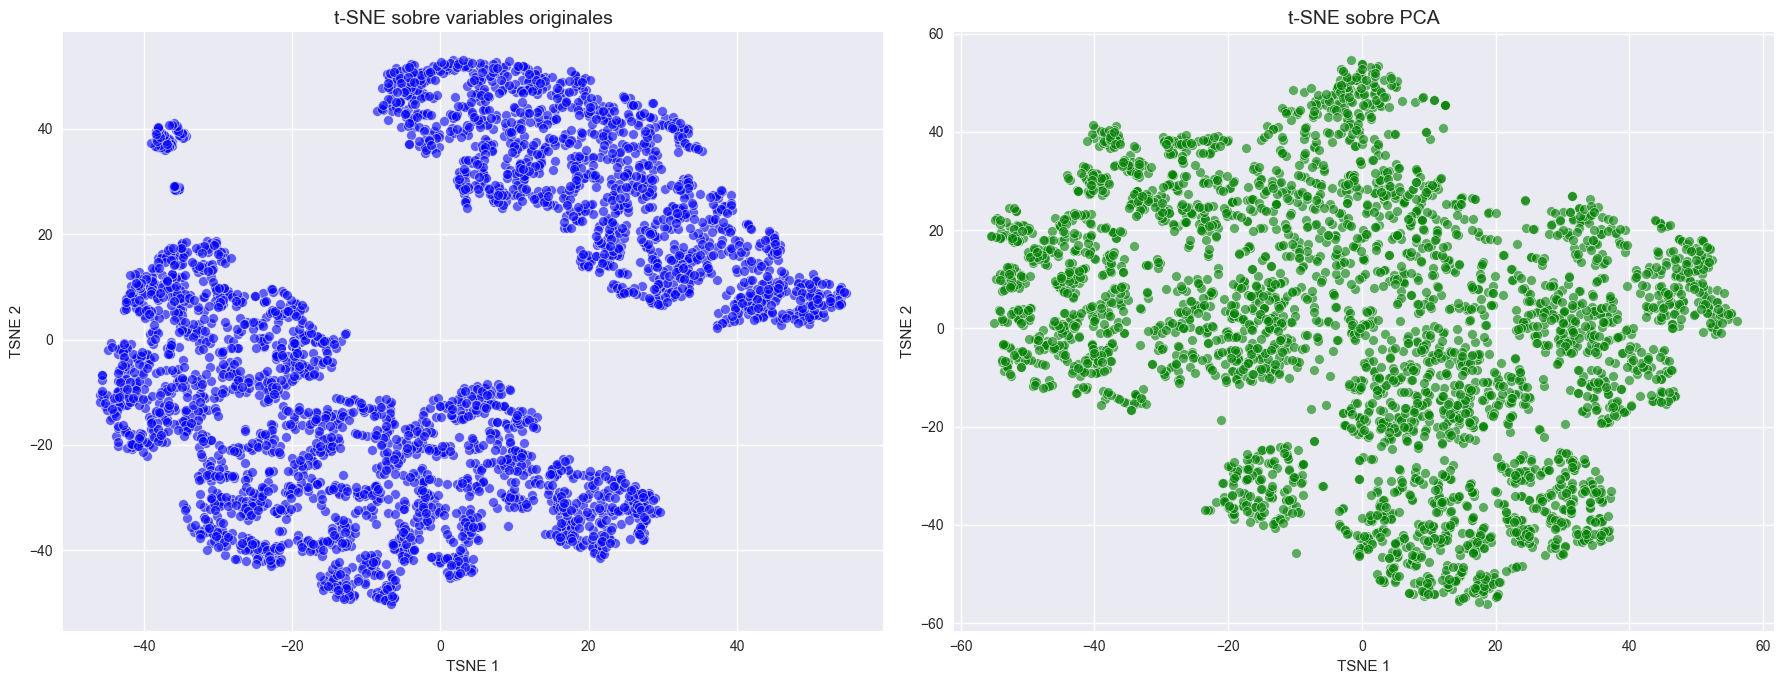

In [106]:
graficar_comparativo_tsne(df_tsne_norm, df_tsne_pca)

In [ ]:
# Análisis de inercia para determinar número óptimo de clusters

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from IPython.display import display

rango_clusters = range(2, 15)
X_input = X_pca

inertias = []
for k in rango_clusters:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    modelo.fit(X_input)
    inertias.append(modelo.inertia_)

df_inercia = pd.DataFrame({
    'Clusters': list(rango_clusters),
    'Inercia_Millones': np.array(inertias) / 1e6
})

df_inercia['Reduccion_vs_Anterior_pct'] = (
    (df_inercia['Inercia_Millones'].shift(1) - df_inercia['Inercia_Millones'])
    / df_inercia['Inercia_Millones'].shift(1)
) * 100

print("\n=== Inercia y reducción relativa por número de clusters ===\n")
display(df_inercia.round(3).reset_index(drop=True))


=== Inercia y reducción relativa por número de clusters ===



,Clusters,Inercia_Millones,Reduccion_vs_Anterior_pct
0,2,0.044,NaN
1,3,0.038,13.563
2,4,0.035,7.983
3,5,0.032,7.304
4,6,0.031,5.921
5,7,0.029,5.278
6,8,0.026,9.361
7,9,0.025,5.396
8,10,0.024,3.522
9,11,0.023,5.245


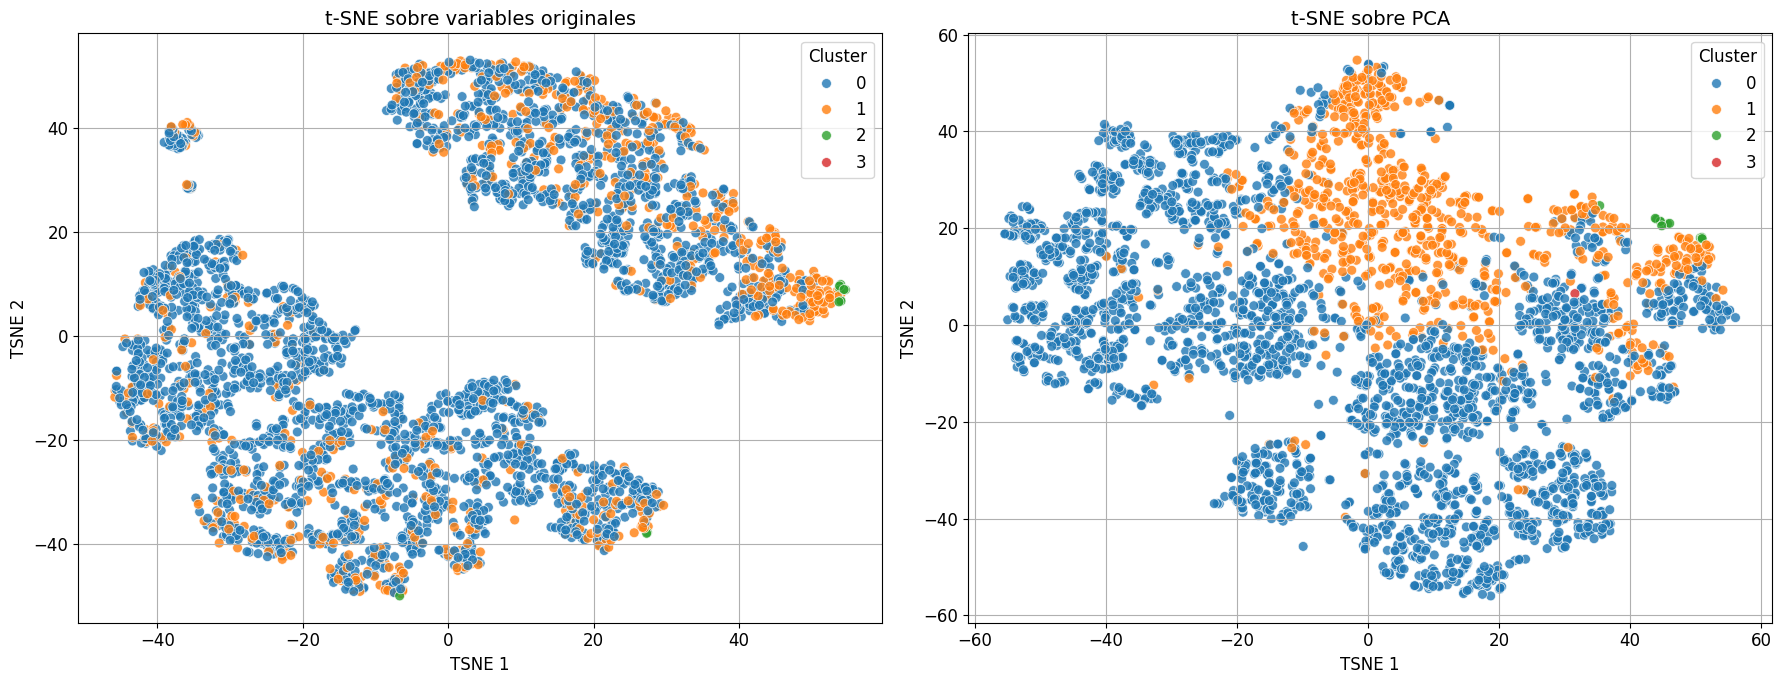

In [67]:
etiquetas_kmeans, modelo_kmeans = aplicar_kmeans(X_pca, n_clusters=4)
graficar_comparativo_tsne(df_tsne_norm, df_tsne_pca, etiquetas=etiquetas_kmeans)

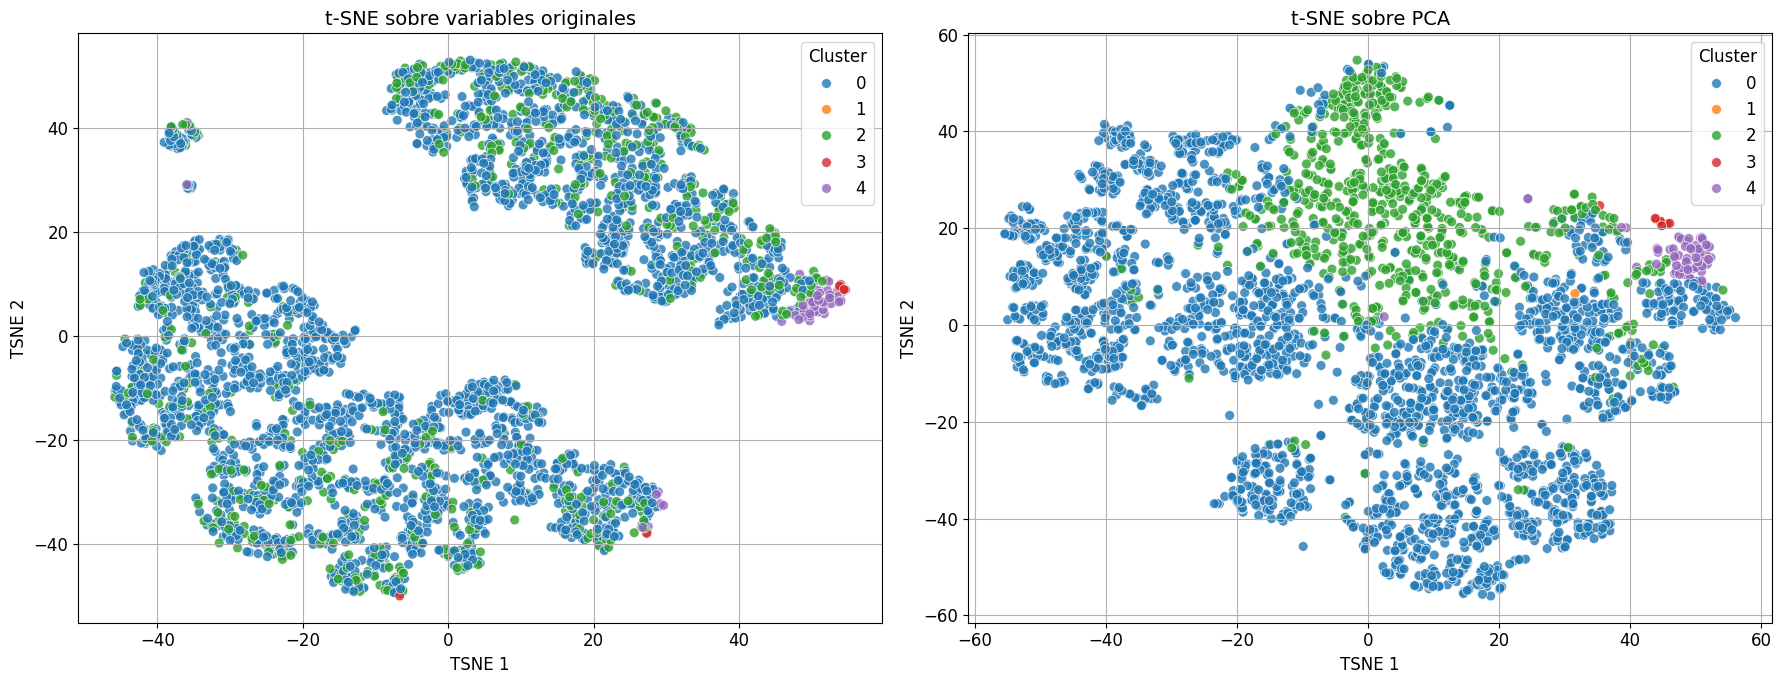

In [68]:
etiquetas_kmeans, modelo_kmeans = aplicar_kmeans(X_pca, n_clusters=5)
graficar_comparativo_tsne(df_tsne_norm, df_tsne_pca, etiquetas=etiquetas_kmeans)

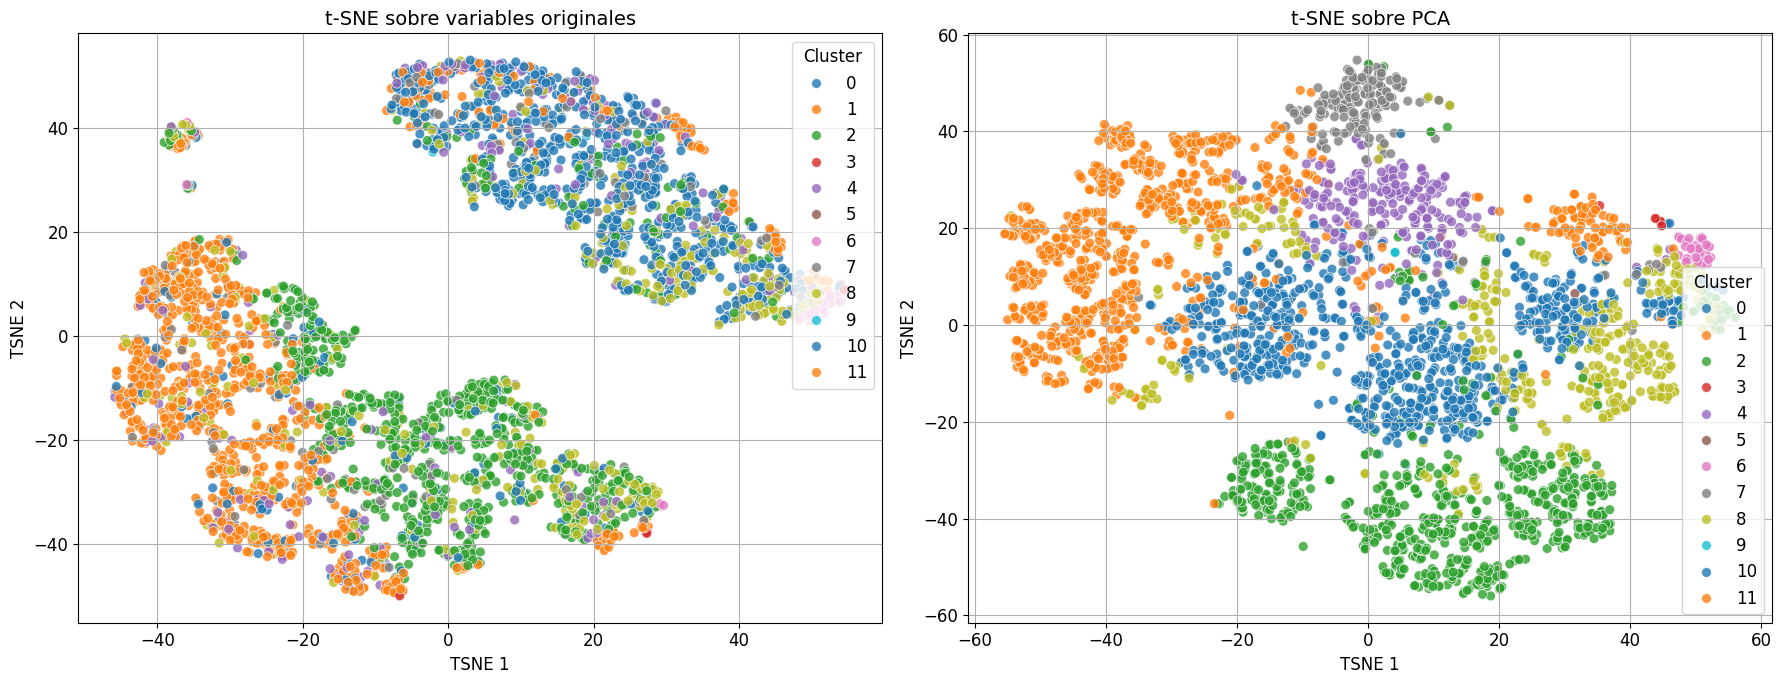

In [69]:
etiquetas_kmeans, modelo_kmeans = aplicar_kmeans(X_pca, n_clusters=12)
graficar_comparativo_tsne(df_tsne_norm, df_tsne_pca, etiquetas=etiquetas_kmeans)

# Probemos DBSCAN, que no define clusters ex-ante

---

## ¿Qué es DBSCAN?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de clustering basado en densidad.
No necesita especificar el número de clusters a priori.

**Idea central:**
- Los puntos que están densamente agrupados forman un cluster.
- Los puntos aislados se consideran ruido (label = -1).

---

## ¿Cómo funciona?

1. **Para cada punto:**
   - Se mira su vecindario de radio eps.
   - Si hay al menos min_samples puntos en ese vecindario, es un punto núcleo.

2. **Un cluster se forma conectando todos los puntos núcleo y sus vecinos alcanzables.**

3. **Puntos que no son núcleo y no están en un vecindario de un núcleo se consideran ruido.**

---

## Principales parámetros

| Parámetro | Qué hace |
|-----------|----------|
| eps | Radio de búsqueda alrededor de cada punto. |
| min_samples | Mínimo número de puntos en ese radio para formar un núcleo. |
| metric | Métrica de distancia (por defecto Euclidean). |

---

## Interpretación práctica

- **eps bajo:** muchos puntos quedan como ruido.
- **eps alto:** clusters muy grandes y difusos.
- **min_samples alto:** se requiere más densidad para formar clusters.

---

## Etiquetas en la salida

- Cada punto recibe una etiqueta numérica de cluster.
- Si es ruido, la etiqueta es -1.

**Ejemplo:**

| Cluster | Cantidad |
|---------|----------|
| -1 | 125 |
| 0 | 450 |
| 1 | 300 |

En este caso hay 2 clusters y 125 puntos de ruido.

---

## Ventajas

- No hay que decir cuántos clusters hay.
- Encuentra clusters de forma arbitraria (no solo esferas).
- Identifica puntos atípicos (ruido).

---



=== Distribución de casos por cluster DBSCAN ===



,Cluster,Cantidad
0,-1,233
1,0,3274


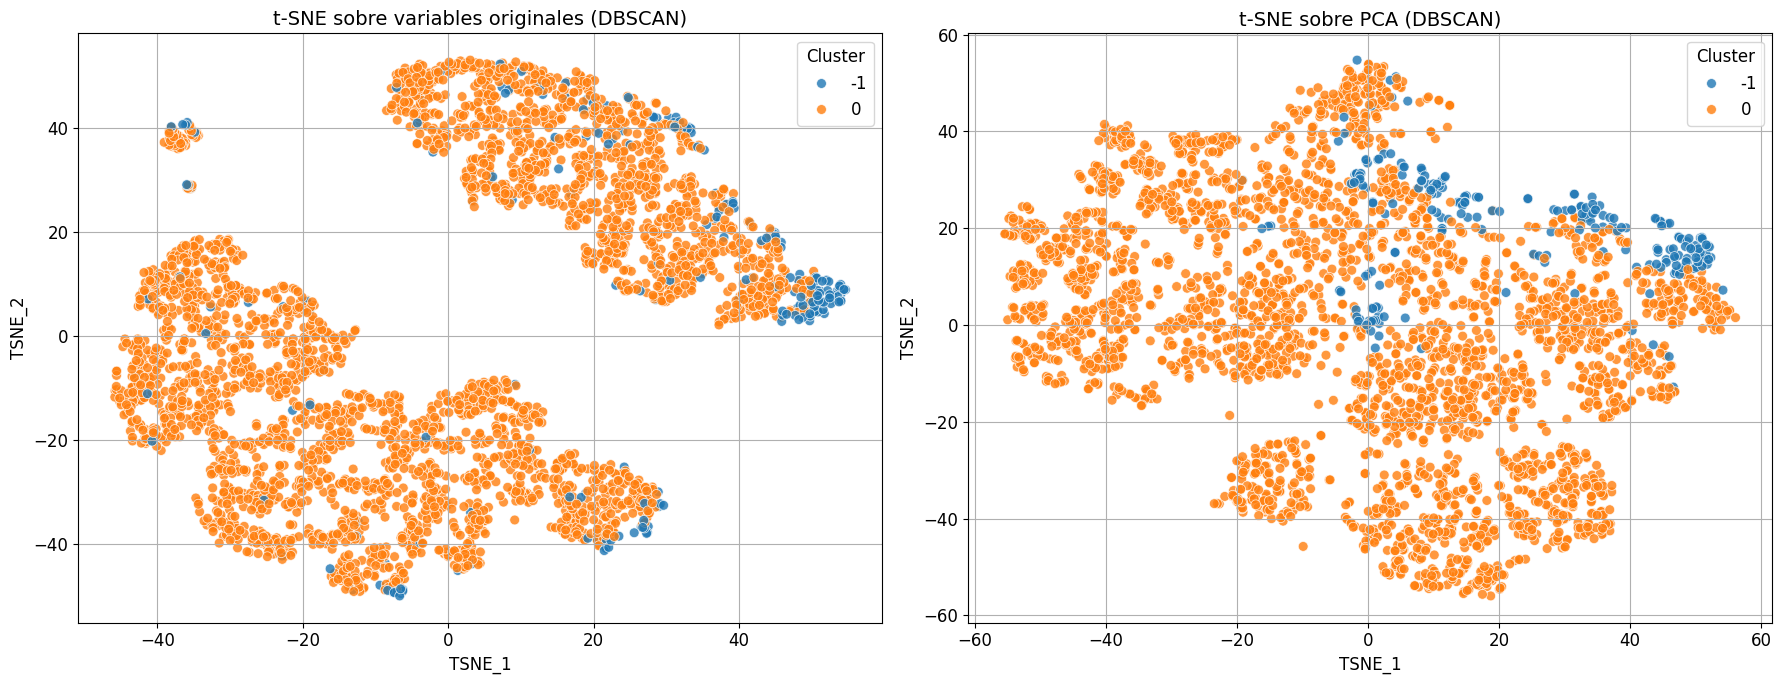

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from IPython.display import display

# Configurar matriz de entrada para DBSCAN
X_input = X_pca

# Aplicar DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=10)
etiquetas_dbscan = dbscan.fit_predict(X_input)

# Generar reporte de clusters
unique, counts = np.unique(etiquetas_dbscan, return_counts=True)
df_resumen = pd.DataFrame({"Cluster": unique, "Cantidad": counts})
print("\n=== Distribución de casos por cluster DBSCAN ===\n")
display(df_resumen)

# Preparar datos para visualización
df_tsne_norm_copy = df_tsne_norm.copy()
df_tsne_pca_copy = df_tsne_pca.copy()
df_tsne_norm_copy["Cluster"] = etiquetas_dbscan
df_tsne_pca_copy["Cluster"] = etiquetas_dbscan

# Crear gráficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico t-SNE sobre variables originales
sns.scatterplot(
    data=df_tsne_norm_copy,
    x="TSNE_1",
    y="TSNE_2",
    hue="Cluster",
    palette="tab10",
    alpha=0.8,
    s=50,
    ax=axes[0]
)
axes[0].set_title("t-SNE sobre variables originales (DBSCAN)", fontsize=14)
axes[0].grid(True)

# Gráfico t-SNE sobre PCA
sns.scatterplot(
    data=df_tsne_pca_copy,
    x="TSNE_1",
    y="TSNE_2",
    hue="Cluster",
    palette="tab10",
    alpha=0.8,
    s=50,
    ax=axes[1]
)
axes[1].set_title("t-SNE sobre PCA (DBSCAN)", fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()


=== Distribución de casos por cluster DBSCAN ===



,Cluster,Cantidad
0,-1,2645
1,0,298
2,1,522
3,2,25
4,3,17


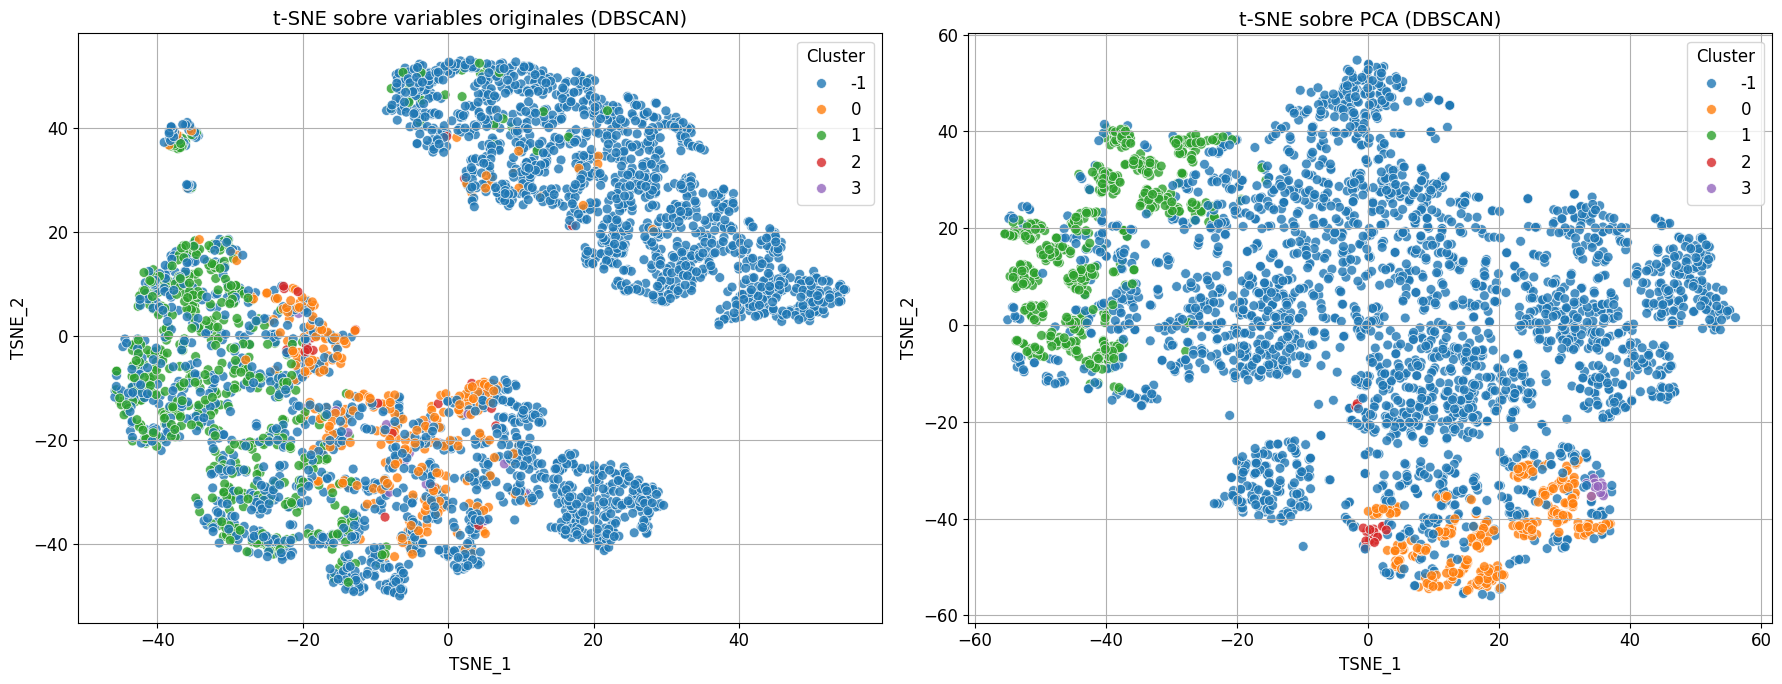

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from IPython.display import display

# Configurar matriz de entrada para DBSCAN
X_input = X_pca

# Aplicar DBSCAN
dbscan = DBSCAN(eps=1, min_samples=10)
etiquetas_dbscan = dbscan.fit_predict(X_input)

# Generar reporte de clusters
unique, counts = np.unique(etiquetas_dbscan, return_counts=True)
df_resumen = pd.DataFrame({"Cluster": unique, "Cantidad": counts})
print("\n=== Distribución de casos por cluster DBSCAN ===\n")
display(df_resumen)

# Preparar datos para visualización
df_tsne_norm_copy = df_tsne_norm.copy()
df_tsne_pca_copy = df_tsne_pca.copy()
df_tsne_norm_copy["Cluster"] = etiquetas_dbscan
df_tsne_pca_copy["Cluster"] = etiquetas_dbscan

# Crear gráficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico t-SNE sobre variables originales
sns.scatterplot(
    data=df_tsne_norm_copy,
    x="TSNE_1",
    y="TSNE_2",
    hue="Cluster",
    palette="tab10",
    alpha=0.8,
    s=50,
    ax=axes[0]
)
axes[0].set_title("t-SNE sobre variables originales (DBSCAN)", fontsize=14)
axes[0].grid(True)

# Gráfico t-SNE sobre PCA
sns.scatterplot(
    data=df_tsne_pca_copy,
    x="TSNE_1",
    y="TSNE_2",
    hue="Cluster",
    palette="tab10",
    alpha=0.8,
    s=50,
    ax=axes[1]
)
axes[1].set_title("t-SNE sobre PCA (DBSCAN)", fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Preparar datos para análisis de perfiles
df_vars = pd.DataFrame(X_norm, columns=variables_finales)
df_vars["Cluster"] = etiquetas_dbscan

# Media global de cada variable
media_global = df_vars.drop(columns="Cluster").mean()

# Obtener los clusters únicos
clusters_unicos = sorted(df_vars["Cluster"].unique())

# Loop por cluster
for cluster in clusters_unicos:
    df_c = df_vars[df_vars["Cluster"] == cluster]
    n = len(df_c)

    # Suma absoluta por variable
    suma_abs = df_c.drop(columns="Cluster").abs().sum()
    total_abs = suma_abs.sum()
    porcentaje = (suma_abs / total_abs) * 100

    # Media por variable en el cluster
    media_cluster = df_c.drop(columns="Cluster").mean()

    # Diferencia con la media global
    dif_media = media_cluster - media_global

    # Unir resultados
    resumen = pd.DataFrame({
        "Porcentaje": porcentaje,
        "DiferenciaMedia": dif_media
    })

    # Ordenar por importancia
    resumen_ordenado = resumen.sort_values(by="Porcentaje", ascending=False)

    # Mostrar
    print(f"\n--- CLUSTER {cluster} ---\n")
    for i, (var, row) in enumerate(resumen_ordenado.iterrows(), 1):
        porc = row["Porcentaje"]
        diff = row["DiferenciaMedia"]
        signo = "+" if diff >=0 else "-"
        print(f"{i}. {var:40s} {porc:.2f}% ({signo}{abs(diff):.2f})")


--- CLUSTER -1 ---

1. log_indice_inversion                     22.33% (+0.22)
2. log_inversion_AI_pcapita_prom            22.33% (+0.22)
3. log_empleo_total_prom                    18.66% (+0.17)
4. log_ventas_totales_prom                  14.02% (+0.14)
5. log_ventas_prom_pcapita                  12.08% (+0.10)
6. log_renta_prom_pcapita                   10.59% (+0.07)

--- CLUSTER 0 ---

1. log_indice_inversion                     26.33% (-0.68)
2. log_inversion_AI_pcapita_prom            26.33% (-0.68)
3. log_ventas_prom_pcapita                  14.73% (-0.23)
4. log_renta_prom_pcapita                   14.10% (-0.18)
5. log_ventas_totales_prom                  10.13% (-0.15)
6. log_empleo_total_prom                    8.38% (-0.01)

--- CLUSTER 1 ---

1. log_empleo_total_prom                    20.42% (-0.84)
2. log_indice_inversion                     20.04% (-0.68)
3. log_inversion_AI_pcapita_prom            20.04% (-0.68)
4. log_ventas_totales_prom                  15.37% (-0.


# Perfiles de clusters DBSCAN

## Cluster -1: "Empresas Aisladas"
**Nota técnica:** En DBSCAN, el cluster -1 representa puntos clasificados como ruido (no pertenecen a ningún cluster denso).

**Perfil:** Empresas con inversión per cápita y agregada ligeramente superiores al promedio, tamaño empresarial intermedio-alto y rentabilidad algo mayor que la media. Son unidades de mayor escala con intensidad inversora moderadamente superior.

---

## Cluster 0: "Empresas de Baja Inversión"
**Perfil:** Empresas con los niveles más bajos de inversión relativa (tanto per cápita como agregada). Presentan rentabilidad y ventas moderadamente inferiores al promedio, con empleo equivalente a la media. Son unidades con menor intensidad inversora y desempeño económico medio-bajo.

---

## Cluster 1: "Empresas Pequeñas con Limitaciones"
**Perfil:** El grupo con menor nivel de empleo, ventas e inversión claramente por debajo del promedio. Las diferencias negativas son más pronunciadas en tamaño y facturación. Representan empresas pequeñas con bajos niveles de inversión y rendimiento económico limitado.

---

## Cluster 2: "Empresas Conservadoras"
**Perfil:** Combina niveles de inversión inferiores al promedio con empleo levemente superior. Las ventas y rentabilidad están por debajo de la media, aunque sin extremos. Son firmas con menor intensidad inversora pero capacidad de sostener el empleo.

---

## Cluster 3: "Empresas Inversoras Intensivas"
**Perfil:** El grupo con la mayor proporción de inversión sobre el total, pero con rentabilidad apenas superior a la media y ventas moderadas. Son empresas con alta propensión a invertir en relación con su tamaño, aunque no necesariamente traducen esto en mayores resultados económicos.



## Tree


R² del modelo: -0.2542

Importancia de cada componente en el árbol:
Componente  Importancia
       PC1       0.3364
       PC3       0.1621
      PC20       0.0955
      PC14       0.0847
       PC5       0.0711
       PC6       0.0651
      PC17       0.0455
       PC8       0.0416
       PC9       0.0405
      PC15       0.0367
      PC11       0.0210
      PC19       0.0000
      PC18       0.0000
      PC16       0.0000
       PC4       0.0000
      PC13       0.0000
       PC2       0.0000
      PC10       0.0000
       PC7       0.0000
      PC12       0.0000

=== Reglas del árbol de decisión ===

|--- PC1 <= -0.54
|   |--- PC1 <= -0.95
|   |   |--- PC3 <= -0.11
|   |   |   |--- PC3 <= -1.17
|   |   |   |   |--- value: [-6.91]
|   |   |   |--- PC3 >  -1.17
|   |   |   |   |--- PC11 <= -0.38
|   |   |   |   |   |--- value: [5.64]
|   |   |   |   |--- PC11 >  -0.38
|   |   |   |   |   |--- value: [8.58]
|   |   |--- PC3 >  -0.11
|   |   |   |--- PC20 <= 0.07
|   |   |   |   |--- v

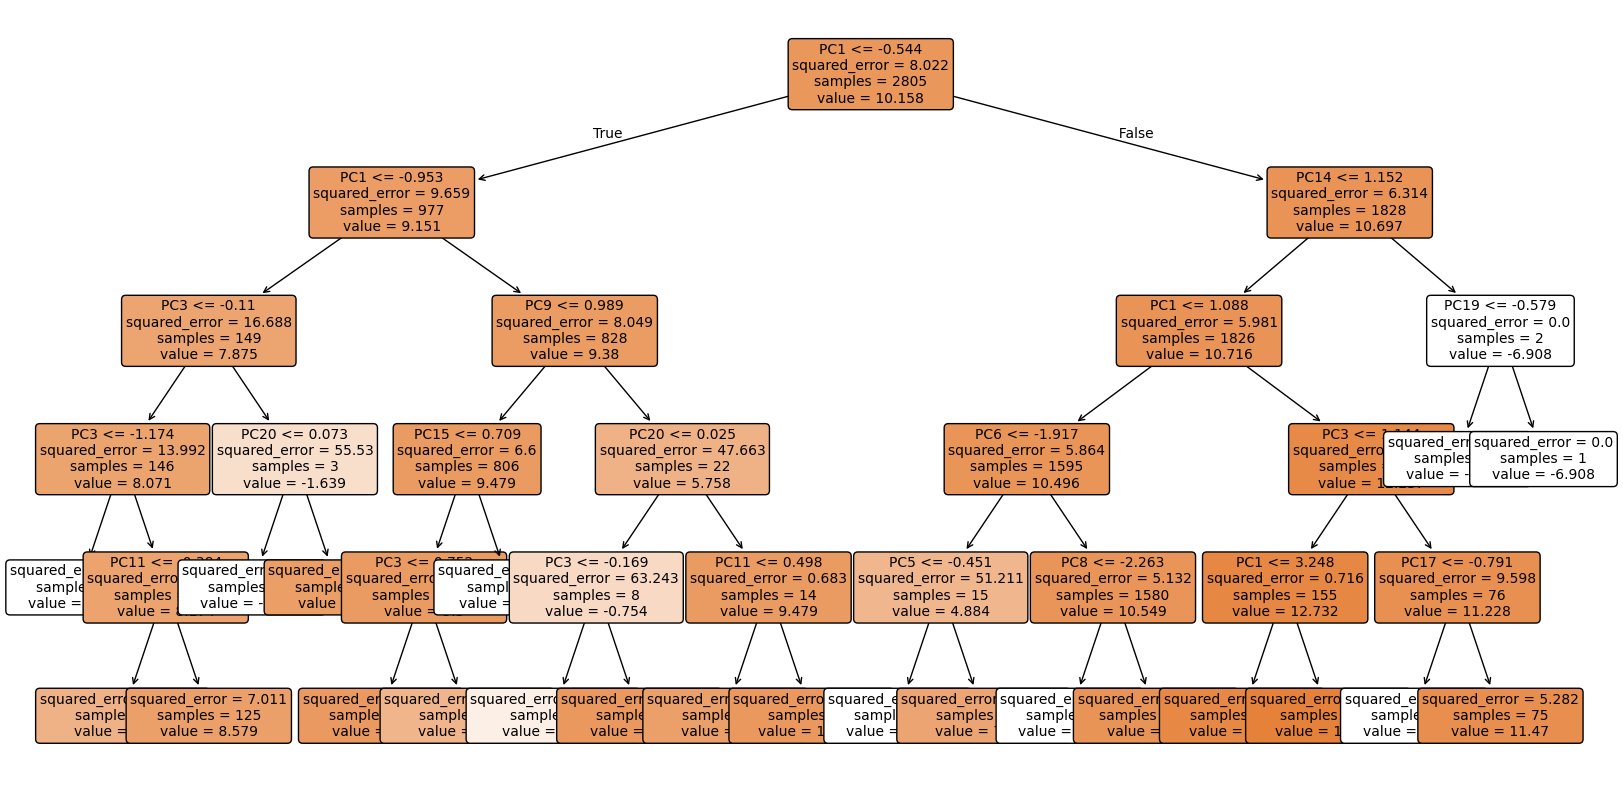

In [74]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# === Target ===
y = df["log_renta_prom_pcapita"].values

# === División entrenamiento/test ===
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

# === Modelo ===
arbol = DecisionTreeRegressor(max_depth=5, random_state=42)
arbol.fit(X_train, y_train)

# === Predicciones ===
y_pred = arbol.predict(X_test)

# === R² ===
r2 = r2_score(y_test, y_pred)
print(f"\nR² del modelo: {r2:.4f}")

# === Importancia de componentes ===
importancias = arbol.feature_importances_
df_importancias = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(importancias))],
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

print("\nImportancia de cada componente en el árbol:")
print(df_importancias.to_string(index=False, float_format="%.4f"))

# === Texto con las reglas del árbol ===
tree_rules = export_text(
    arbol,
    feature_names=[f"PC{i+1}" for i in range(X_pca.shape[1])],
    decimals=2
)
print("\n=== Reglas del árbol de decisión ===\n")
print(tree_rules)

# === Gráfico del árbol ===
plt.figure(figsize=(20,10))
plot_tree(
    arbol,
    feature_names=[f"PC{i+1}" for i in range(X_pca.shape[1])],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


R² del modelo: 0.9951

Importancia de cada variable en el árbol:
                     Variable  Importancia
       log_renta_prom_pcapita       0.9989
      log_ventas_prom_pcapita       0.0011
        log_empleo_total_prom       0.0000
      log_ventas_totales_prom       0.0000
log_inversion_AI_pcapita_prom       0.0000
         log_indice_inversion       0.0000

=== Reglas del árbol de decisión ===

|--- log_renta_prom_pcapita <= -4.03
|   |--- log_empleo_total_prom <= -0.94
|   |   |--- log_ventas_prom_pcapita <= -6.66
|   |   |   |--- value: [-6.91]
|   |   |--- log_ventas_prom_pcapita >  -6.66
|   |   |   |--- log_empleo_total_prom <= -1.24
|   |   |   |   |--- value: [-6.91]
|   |   |   |--- log_empleo_total_prom >  -1.24
|   |   |   |   |--- value: [-6.91]
|   |--- log_empleo_total_prom >  -0.94
|   |   |--- log_ventas_prom_pcapita <= -2.11
|   |   |   |--- value: [-6.91]
|   |   |--- log_ventas_prom_pcapita >  -2.11
|   |   |   |--- log_empleo_total_prom <= -0.90
|   |   |   |

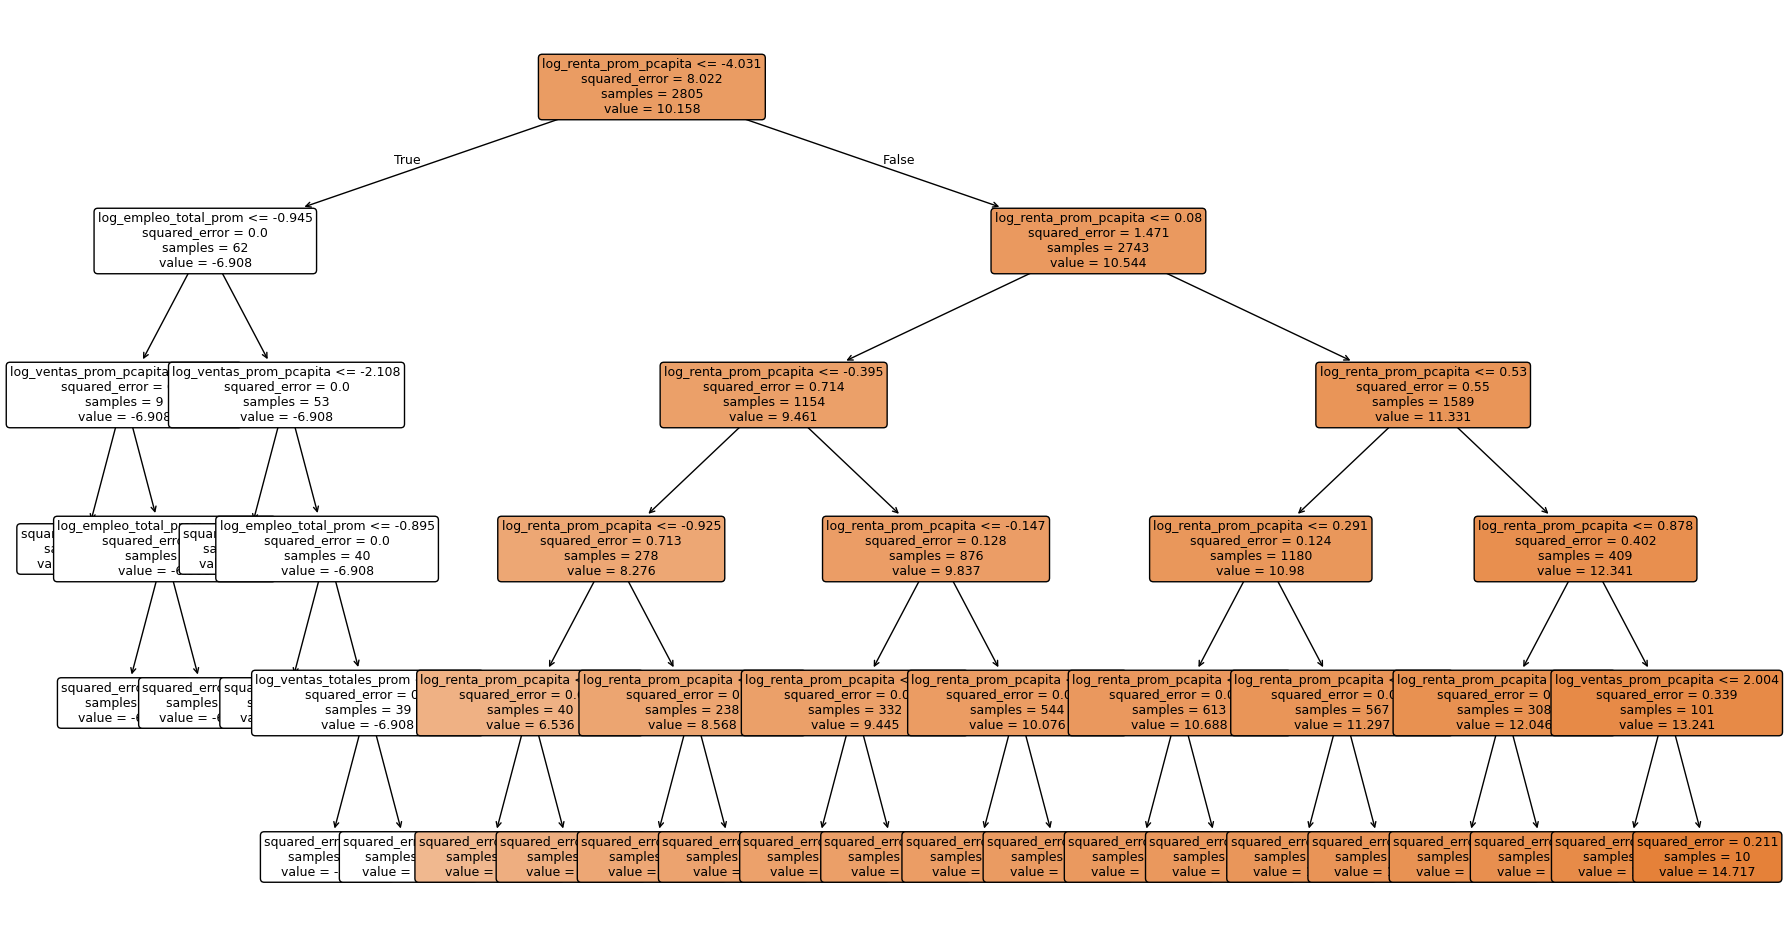

In [76]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# === Target ===
y = df["log_renta_prom_pcapita"].values

# === División entrenamiento/test ===
X_train, X_test, y_train, y_test = train_test_split(
    X_norm,
    y,
    test_size=0.2,
    random_state=42
)

# === Modelo ===
arbol = DecisionTreeRegressor(max_depth=5, random_state=42)
arbol.fit(X_train, y_train)

# === Predicciones ===
y_pred = arbol.predict(X_test)

# === R² ===
r2 = r2_score(y_test, y_pred)
print(f"\nR² del modelo: {r2:.4f}")

# === Importancia de variables originales ===
importancias = arbol.feature_importances_
df_importancias = pd.DataFrame({
    "Variable": variables_finales,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

print("\nImportancia de cada variable en el árbol:")
print(df_importancias.to_string(index=False, float_format="%.4f"))

# === Texto con las reglas del árbol ===
tree_rules = export_text(
    arbol,
    feature_names=variables_finales,
    decimals=2
)
print("\n=== Reglas del árbol de decisión ===\n")
print(tree_rules)

# === Gráfico del árbol ===
plt.figure(figsize=(22,12))
plot_tree(
    arbol,
    feature_names=variables_finales,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()


R² del modelo: 0.2695

Importancia de cada variable en el árbol:
                     Variable  Importancia
      log_ventas_prom_pcapita       0.9681
        log_empleo_total_prom       0.0231
      log_ventas_totales_prom       0.0088
log_inversion_AI_pcapita_prom       0.0000
         log_indice_inversion       0.0000

=== Reglas del árbol de decisión ===

|--- log_ventas_prom_pcapita <= 9.29
|   |--- log_ventas_prom_pcapita <= 8.75
|   |   |--- value: [-3.68]
|   |--- log_ventas_prom_pcapita >  8.75
|   |   |--- log_ventas_totales_prom <= 16.18
|   |   |   |--- value: [4.11]
|   |   |--- log_ventas_totales_prom >  16.18
|   |   |   |--- value: [2.43]
|--- log_ventas_prom_pcapita >  9.29
|   |--- log_ventas_prom_pcapita <= 10.64
|   |   |--- log_ventas_prom_pcapita <= 9.92
|   |   |   |--- log_empleo_total_prom <= 4.06
|   |   |   |   |--- value: [8.23]
|   |   |   |--- log_empleo_total_prom >  4.06
|   |   |   |   |--- value: [4.94]
|   |   |--- log_ventas_prom_pcapita >  9.92
|  

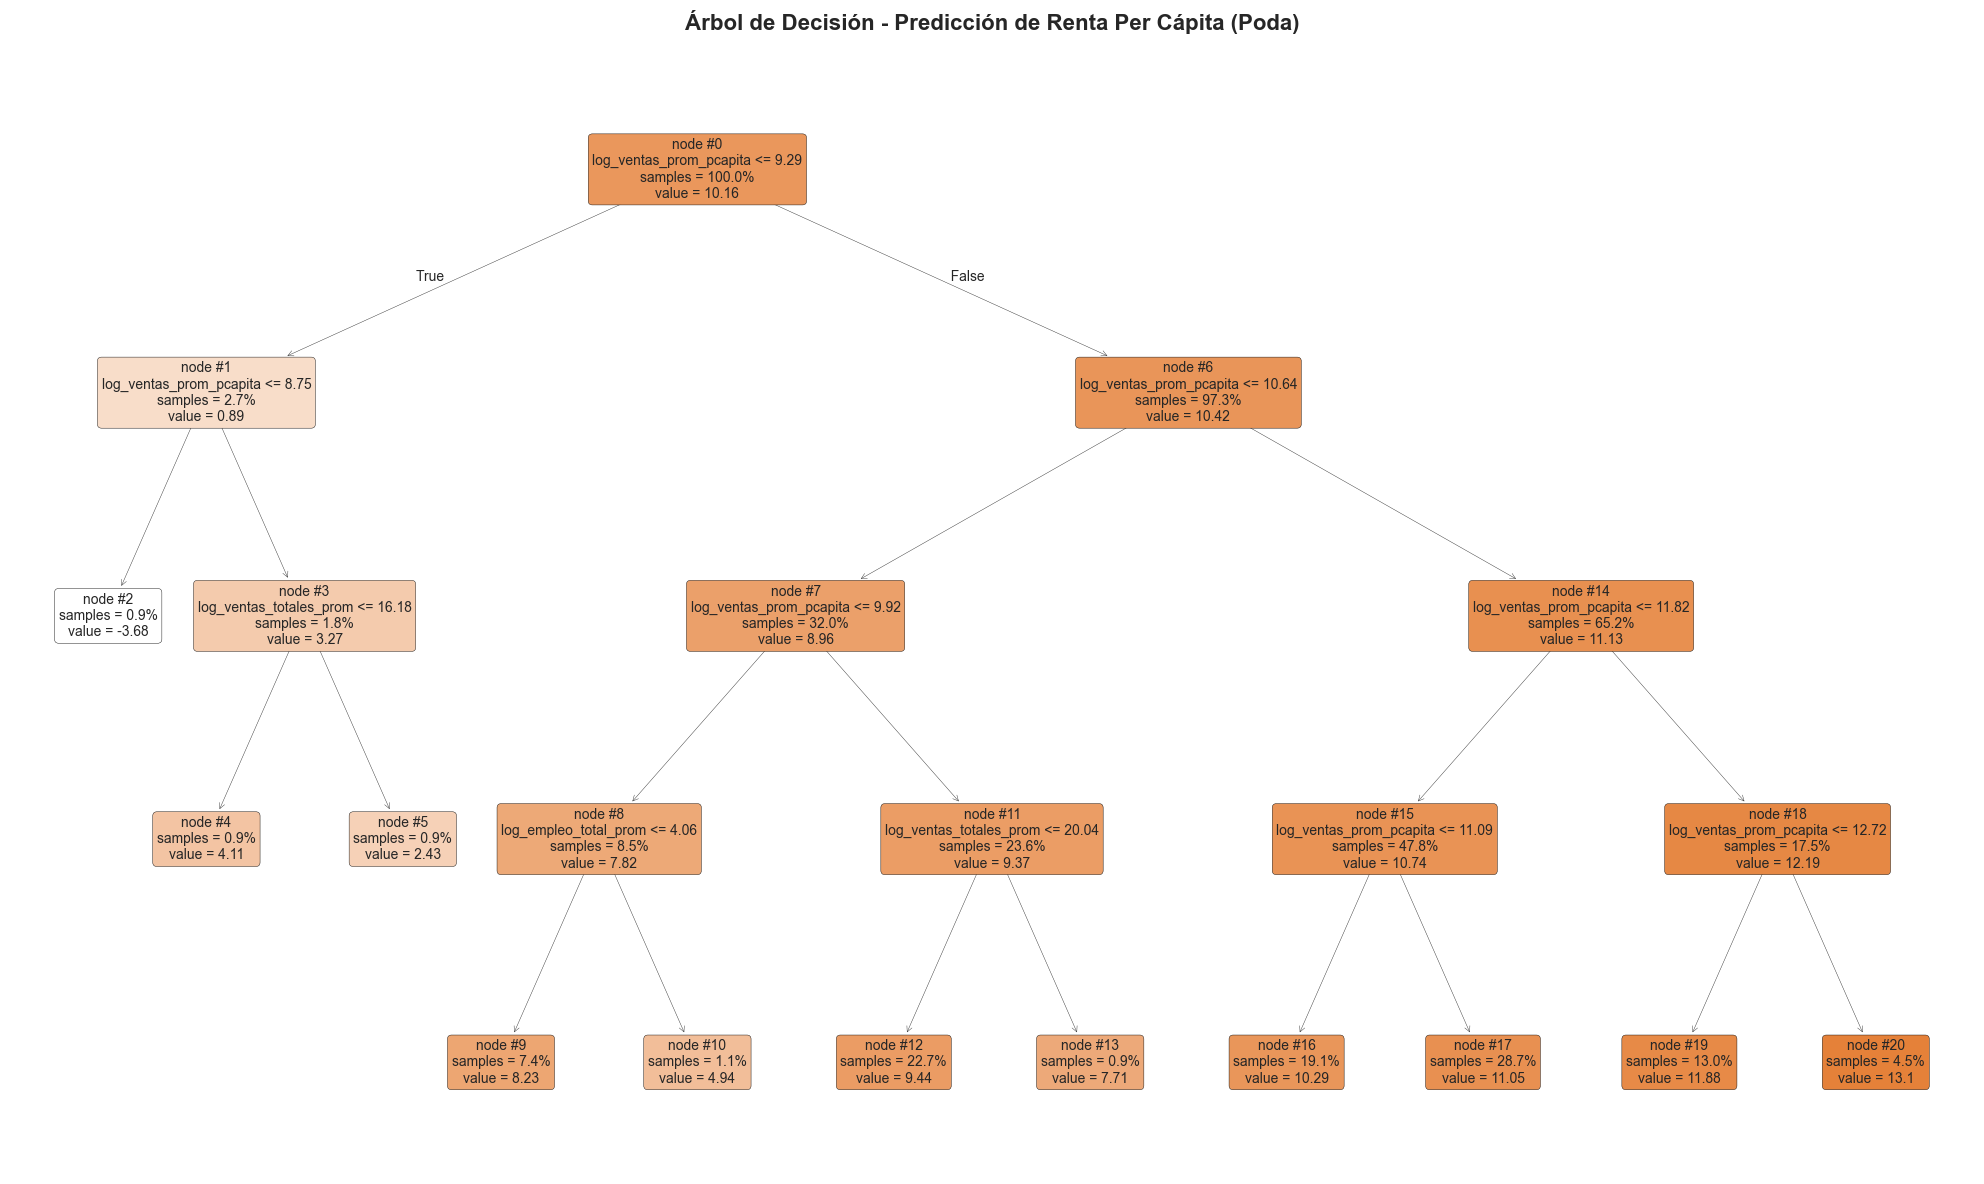

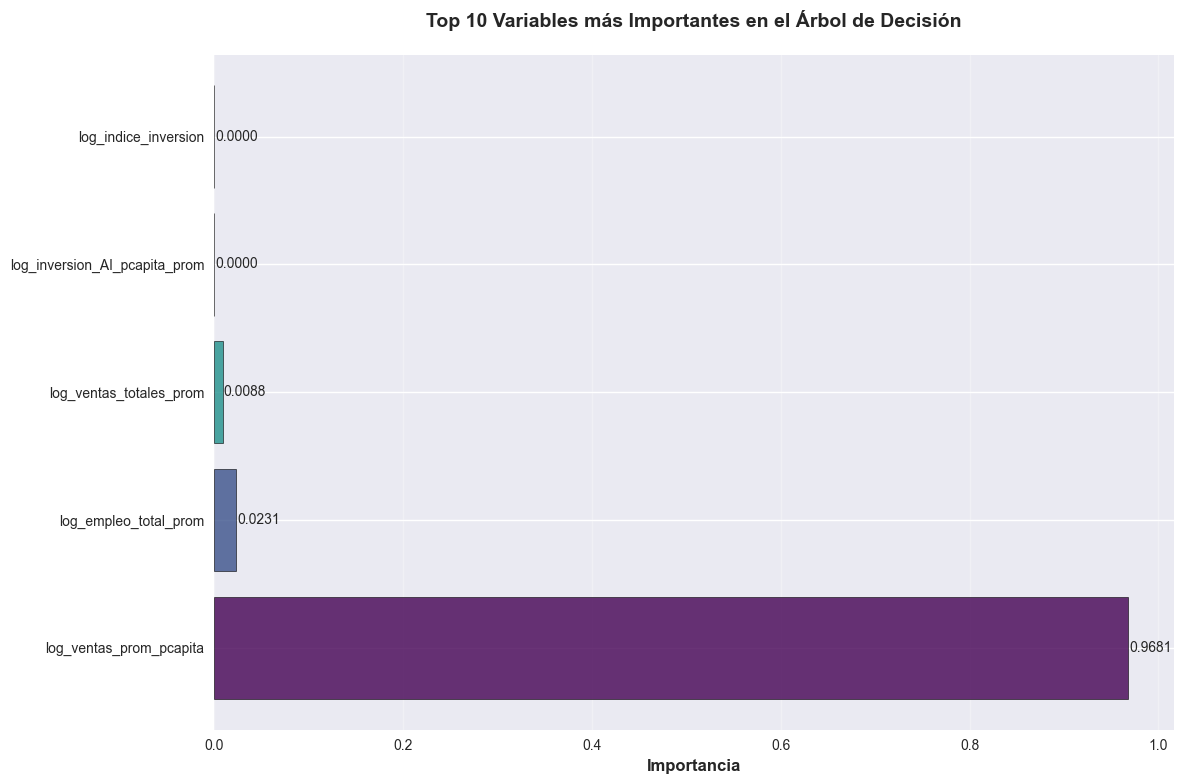


=== Análisis del árbol podado ===
Número total de nodos: 21
Número de hojas: 11
Profundidad máxima: 4

Estadísticas de las hojas:
Mínimo muestras por hoja: 25
Máximo muestras por hoja: 804
Promedio muestras por hoja: 255.0


In [84]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de matplotlib para mejor visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# === Target ===
y = df["log_renta_prom_pcapita"].values

# === Filtrar variables: sin la variable target ===
variables_sin_target = [v for v in variables_finales if v != "log_renta_prom_pcapita"]
X_sin_target = df[variables_sin_target].values

# === División entrenamiento/test ===
X_train, X_test, y_train, y_test = train_test_split(
    X_sin_target,
    y,
    test_size=0.2,
    random_state=42
)

# === Modelo con poda para evitar overfitting ===
arbol = DecisionTreeRegressor(
    max_depth=4,  # Reducir profundidad
    min_samples_split=50,  # Mínimo 50 muestras para dividir
    min_samples_leaf=25,   # Mínimo 25 muestras por hoja
    random_state=42
)
arbol.fit(X_train, y_train)

# === Predicciones ===
y_pred = arbol.predict(X_test)

# === R² ===
r2 = r2_score(y_test, y_pred)
print(f"\nR² del modelo: {r2:.4f}")

# === Importancia de variables ===
importancias = arbol.feature_importances_
df_importancias = pd.DataFrame({
    "Variable": variables_sin_target,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

print("\nImportancia de cada variable en el árbol:")
print(df_importancias.to_string(index=False, float_format="%.4f"))

# === Texto con las reglas del árbol ===
tree_rules = export_text(
    arbol,
    feature_names=variables_sin_target,
    decimals=2
)
print("\n=== Reglas del árbol de decisión ===\n")
print(tree_rules)

# === Gráfico del árbol mejorado y más limpio ===
fig, ax = plt.subplots(figsize=(20, 12))

plot_tree(
    arbol,
    feature_names=variables_sin_target,
    filled=True,
    rounded=True,
    fontsize=10,
    node_ids=True,
    proportion=True,
    precision=2,
    ax=ax,
    impurity=False,
    max_depth=None,
)

# Personalizar el gráfico
ax.set_title('Árbol de Decisión - Predicción de Renta Per Cápita (Poda)', 
             fontsize=16, fontweight='bold', pad=20)

# Ajustar layout para evitar cortes
plt.tight_layout()
plt.show()

# === Gráfico de importancia de variables ===
plt.figure(figsize=(12, 8))
top_10_importancias = df_importancias.head(10)
colors_importancia = plt.cm.viridis(np.linspace(0, 1, len(top_10_importancias)))

bars = plt.barh(range(len(top_10_importancias)), 
                top_10_importancias['Importancia'],
                color=colors_importancia,
                alpha=0.8,
                edgecolor='black',
                linewidth=0.5)

plt.yticks(range(len(top_10_importancias)), top_10_importancias['Variable'])
plt.xlabel('Importancia', fontsize=12, fontweight='bold')
plt.title('Top 10 Variables más Importantes en el Árbol de Decisión', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# === Análisis de nodos del árbol ===
print(f"\n=== Análisis del árbol podado ===")
print(f"Número total de nodos: {arbol.tree_.node_count}")
print(f"Número de hojas: {arbol.get_n_leaves()}")
print(f"Profundidad máxima: {arbol.get_depth()}")

# Mostrar estadísticas de las hojas
leaf_samples = []
for i in range(arbol.tree_.node_count):
    if arbol.tree_.children_left[i] == -1:  # Es una hoja
        leaf_samples.append(arbol.tree_.n_node_samples[i])

print(f"\nEstadísticas de las hojas:")
print(f"Mínimo muestras por hoja: {min(leaf_samples)}")
print(f"Máximo muestras por hoja: {max(leaf_samples)}")
print(f"Promedio muestras por hoja: {np.mean(leaf_samples):.1f}")

### Implicancias

#### Caminos determinantes

**Primer split clave:**
- `log_ventas_prom_pcapita <= 9.29`
- Esto divide empresas de baja vs. alta venta per cápita

**Comportamiento según el split:**
- Si menor, se asignan predicciones muy bajas (en algunos nodos -6.91)
- Si mayor, se subdivide por ventas y empleo

**Segmentos con renta más alta:**
- `log_ventas_prom_pcapita > 11.82` y `log_ventas_prom_pcapita <= 13.96` → renta ~12.9
- `log_ventas_prom_pcapita > 13.96` → renta ~14.7

**Segmentos intermedios:**
- Ventas per cápita entre ~9 y ~11 → renta ~8-10

**Segmentos más bajos:**
- Ventas per cápita ≤ 7.71 → renta muy negativa (~-6.91)


KeyError: 'rentabilidad'